<a href="https://colab.research.google.com/github/hanazee-04/Case-study-on-Unsupervised-Analysis-of-Mars-Rover-Environmental-Data-Using-ML/blob/main/Mars_unsupervised_ML__Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **AIR- CA 1**
## CASE STUDY BASED ASSIGNMENT

## Project title: Unsupervised Analysis of Mars Rover Environmental Data using Machine Learning and Deep Learning

## SOURCE- Kaggle

## TEAM-

##     ZAHRA MODI

##     AMEYA SHANDILYA

##     BHAVESH SHARMA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv(r"D:\USER DATA\Downloads\REMS_Mars_Dataset.csv")

# Preview data
df.head()

,earth_date_time,mars_date_time,sol_number,max_ground_temp(°C),min_ground_temp(°C),max_air_temp(°C),min_air_temp(°C),mean_pressure(Pa),wind_speed(m/h),humidity(%),sunrise,sunset,UV_Radiation,weather
0,"Earth, 2022-01-26 UTC","Mars, Month 6 - LS 163°",Sol 3368,-3,-71,10,-84,707,Value not available,Value not available,05:25,17:20,moderate,Sunny
1,"Earth, 2022-01-25 UTC","Mars, Month 6 - LS 163°",Sol 3367,-3,-72,10,-87,707,Value not available,Value not available,05:25,17:20,moderate,Sunny
2,"Earth, 2022-01-24 UTC","Mars, Month 6 - LS 162°",Sol 3366,-4,-70,8,-81,708,Value not available,Value not available,05:25,17:21,moderate,Sunny
3,"Earth, 2022-01-23 UTC","Mars, Month 6 - LS 162°",Sol 3365,-6,-70,9,-91,707,Value not available,Value not available,05:26,17:21,moderate,Sunny
4,"Earth, 2022-01-22 UTC","Mars, Month 6 - LS 161°",Sol 3364,-7,-71,8,-92,708,Value not available,Value not available,05:26,17:21,moderate,Sunny


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   earth_date_time      3197 non-null   object
 1   mars_date_time       3197 non-null   object
 2   sol_number           3197 non-null   object
 3   max_ground_temp(°C)  3197 non-null   object
 4   min_ground_temp(°C)  3197 non-null   object
 5   max_air_temp(°C)     3197 non-null   object
 6   min_air_temp(°C)     3197 non-null   object
 7   mean_pressure(Pa)    3197 non-null   object
 8   wind_speed(m/h)      3197 non-null   object
 9   humidity(%)          3197 non-null   object
 10  sunrise              3197 non-null   object
 11  sunset               3197 non-null   object
 12  UV_Radiation         3170 non-null   object
 13  weather              3197 non-null   object
dtypes: object(14)
memory usage: 349.8+ KB


In [ ]:
df.columns

Index(['earth_date_time', 'mars_date_time', 'sol_number',
       'max_ground_temp(°C)', 'min_ground_temp(°C)', 'max_air_temp(°C)',
       'min_air_temp(°C)', 'mean_pressure(Pa)', 'wind_speed(m/h)',
       'humidity(%)', 'sunrise', 'sunset', 'UV_Radiation', 'weather'],
      dtype='object')

In [ ]:
df.describe()

,earth_date_time,mars_date_time,sol_number,max_ground_temp(°C),min_ground_temp(°C),max_air_temp(°C),min_air_temp(°C),mean_pressure(Pa),wind_speed(m/h),humidity(%),sunrise,sunset,UV_Radiation,weather
count,3197,3197,3197,3197,3197,3197,3197,3197,3197,3197,3197,3197,3170,3197
unique,3197,360,3197,52,40,51,78,224,1,1,90,96,4,2
top,"Earth, 2012-08-07 UTC","Mars, Month 2 - LS 55°",Sol 1,-6,-79,6,-78,873,Value not available,Value not available,05:18,17:20,moderate,Sunny
freq,1,12,1,130,221,154,165,47,3197,3197,170,199,1450,3194


In [ ]:
df.isnull()

,earth_date_time,mars_date_time,sol_number,max_ground_temp(°C),min_ground_temp(°C),max_air_temp(°C),min_air_temp(°C),mean_pressure(Pa),wind_speed(m/h),humidity(%),sunrise,sunset,UV_Radiation,weather
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3192,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3193,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3194,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3195,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [ ]:
df.replace("value not available", np.nan, inplace=True)

In [ ]:
numeric_cols = [
    'max_ground_temp(°C)', 'min_ground_temp(°C)',
    'max_air_temp(°C)', 'min_air_temp(°C)',
    'mean_pressure(Pa)', 'wind_speed(m/h)',
    'humidity(%)', 'UV_Radiation'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
df['earth_date_time'] = df['earth_date_time'].str.replace("Earth, ", "")
df['earth_date_time'] = df['earth_date_time'].str.replace(" UTC", "")

In [ ]:
df['earth_date_time'] = pd.to_datetime(df['earth_date_time'], errors='coerce')

In [ ]:
df['mars_date_time'].head()

0    Mars, Month 6 - LS 163°
1    Mars, Month 6 - LS 163°
2    Mars, Month 6 - LS 162°
3    Mars, Month 6 - LS 162°
4    Mars, Month 6 - LS 161°
Name: mars_date_time, dtype: object

In [ ]:
df['earth_date_time'].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   earth_date_time      3197 non-null   datetime64[ns]
 1   mars_date_time       3197 non-null   object        
 2   sol_number           3197 non-null   object        
 3   max_ground_temp(°C)  3169 non-null   float64       
 4   min_ground_temp(°C)  3169 non-null   float64       
 5   max_air_temp(°C)     3168 non-null   float64       
 6   min_air_temp(°C)     3168 non-null   float64       
 7   mean_pressure(Pa)    3170 non-null   float64       
 8   wind_speed(m/h)      0 non-null      float64       
 9   humidity(%)          0 non-null      float64       
 10  sunrise              3197 non-null   object        
 11  sunset               3197 non-null   object        
 12  UV_Radiation         0 non-null      float64       
 13  weather              3197 non-nul

In [ ]:
df = df.drop(columns=[
    'wind_speed(m/h)',
    'humidity(%)',
    'UV_Radiation'
])


In [ ]:
df = df.drop(columns=[
    'mars_date_time',
    'sol_number',
    'sunrise',
    'sunset',
    'weather'
])

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

In [ ]:
numeric_df = numeric_df.interpolate()
numeric_df = numeric_df.dropna()

In [ ]:
df[numeric_df.columns] = numeric_df

In [ ]:
df = df.select_dtypes(include=[np.number])
df = df.interpolate()
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3197 entries, 0 to 3196
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   max_ground_temp(°C)  3197 non-null   float64
 1   min_ground_temp(°C)  3197 non-null   float64
 2   max_air_temp(°C)     3197 non-null   float64
 3   min_air_temp(°C)     3197 non-null   float64
 4   mean_pressure(Pa)    3197 non-null   float64
dtypes: float64(5)
memory usage: 125.0 KB


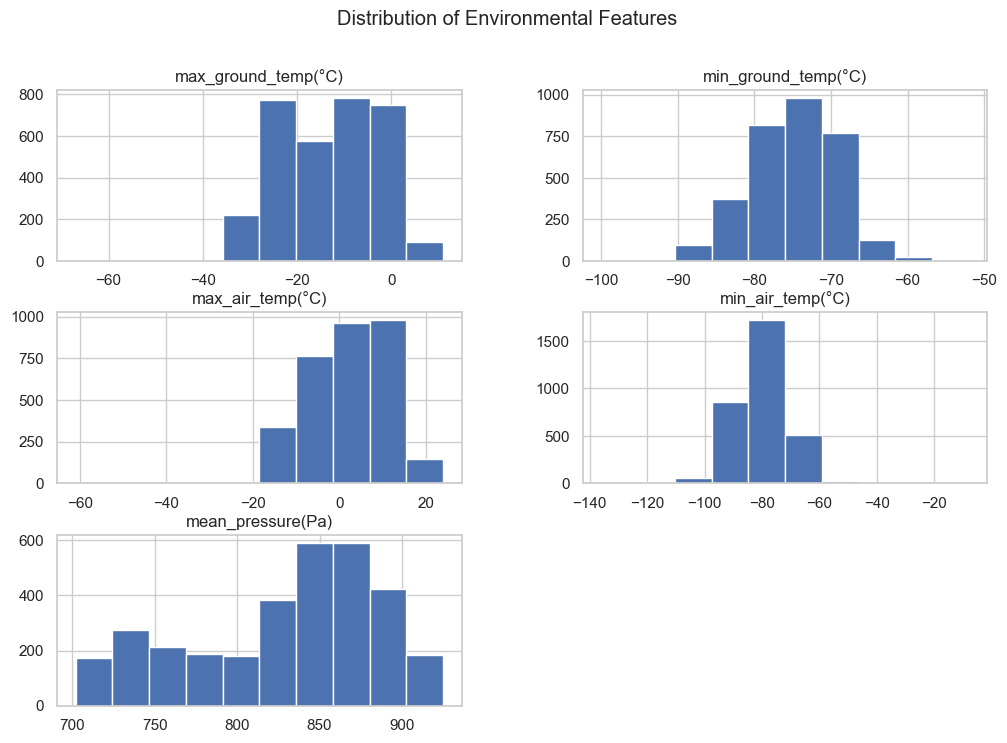

In [ ]:
df.hist(figsize=(12,8))
plt.suptitle("Distribution of Environmental Features")
plt.show()

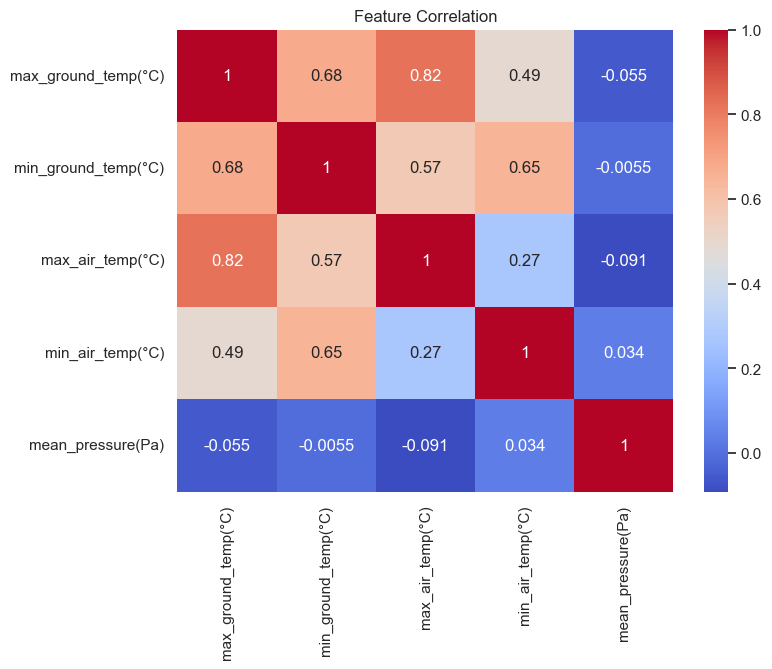

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

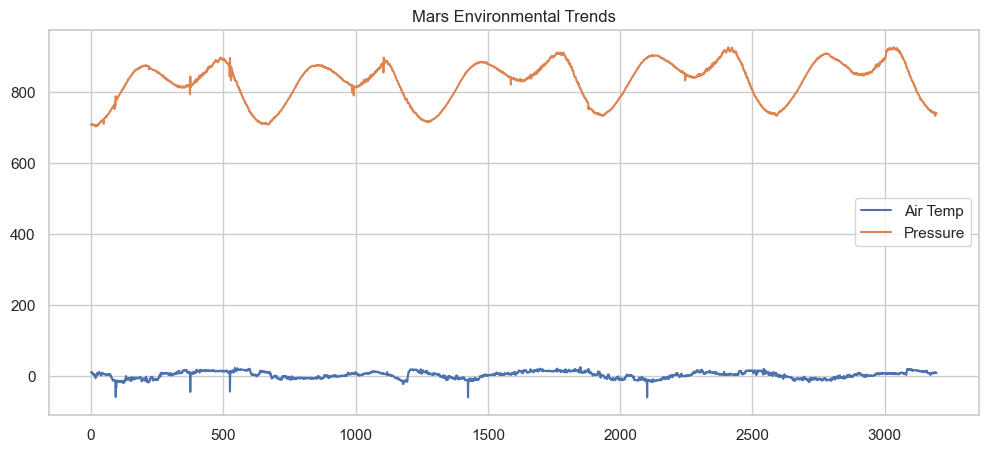

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['max_air_temp(°C)'], label='Air Temp')
plt.plot(df['mean_pressure(Pa)'], label='Pressure')
plt.legend()
plt.title("Mars Environmental Trends")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)
latent = Dense(4, activation='relu')(encoded)

decoded = Dense(8, activation='relu')(latent)
decoded = Dense(16, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 1.0092 - val_loss: 0.9807
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7316 - val_loss: 0.5067
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4334 - val_loss: 0.3616
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3298 - val_loss: 0.3146
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2434 - val_loss: 0.2112
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1754 - val_loss: 0.1514
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1336 - val_loss: 0.1100
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1102 - val_loss: 0.1022
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0952 - val_loss: 0.0867
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0822 - val_loss: 0.0757
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0706 - val_loss: 0.0649
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0595 - val

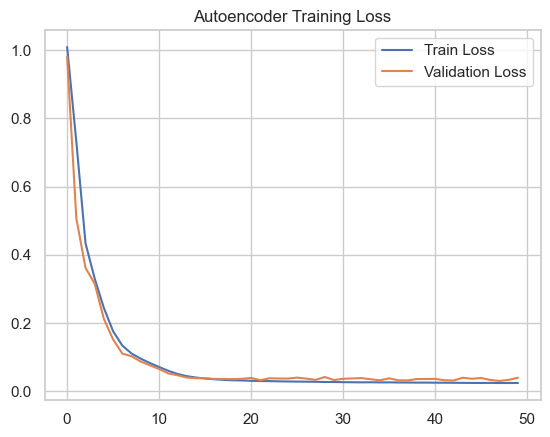

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Autoencoder Training Loss")
plt.show()

In [ ]:
from tensorflow.keras.models import Model

# Encoder model (input → latent layer)
encoder = Model(inputs=autoencoder.input, outputs=autoencoder.layers[3].output)

X_latent = encoder.predict(X_scaled)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_latent)

In [ ]:
df['cluster'] = clusters

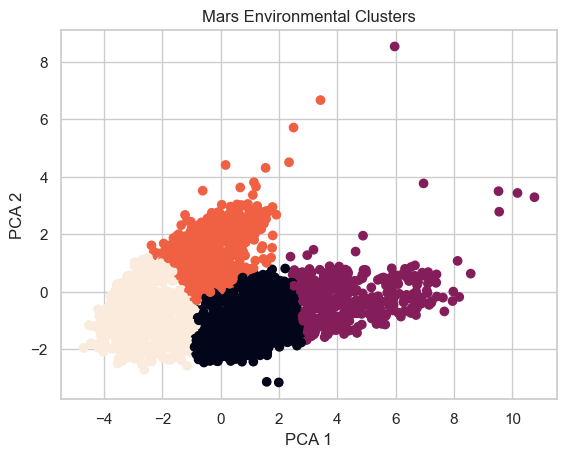

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_latent)

plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Mars Environmental Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

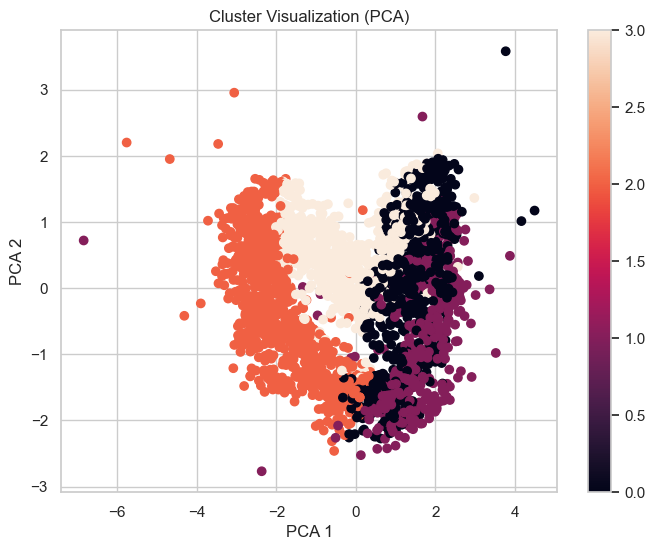

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)

plt.title("Cluster Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_latent, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.36693987250328064


In [ ]:
X_pred = autoencoder.predict(X_scaled)

recon_error = ((X_scaled - X_pred)**2).mean(axis=1)

print("Mean Reconstruction Error:", recon_error.mean())

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Mean Reconstruction Error: 0.02678763398458748


In [ ]:
accuracy = 1 - recon_error.mean()
print("Approx Model Accuracy:", accuracy)

Approx Model Accuracy: 0.9732123660154125


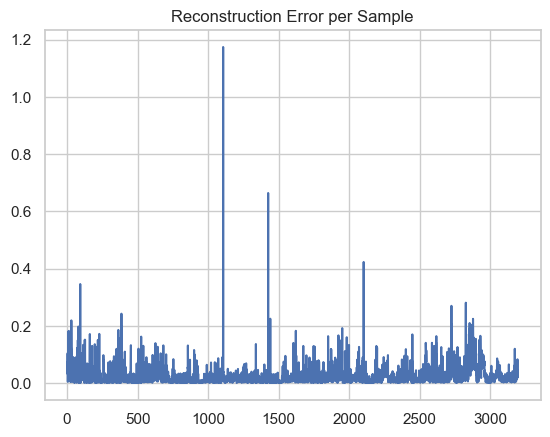

In [ ]:
import matplotlib.pyplot as plt

plt.plot(recon_error)
plt.title("Reconstruction Error per Sample")
plt.show()

In [ ]:
import numpy as np

threshold = np.percentile(recon_error, 95)

df['anomaly'] = recon_error > threshold

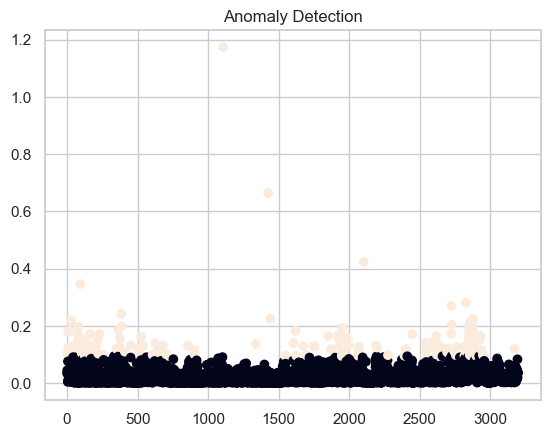

In [ ]:
plt.scatter(range(len(recon_error)), recon_error, c=df['anomaly'])
plt.title("Anomaly Detection")
plt.show()

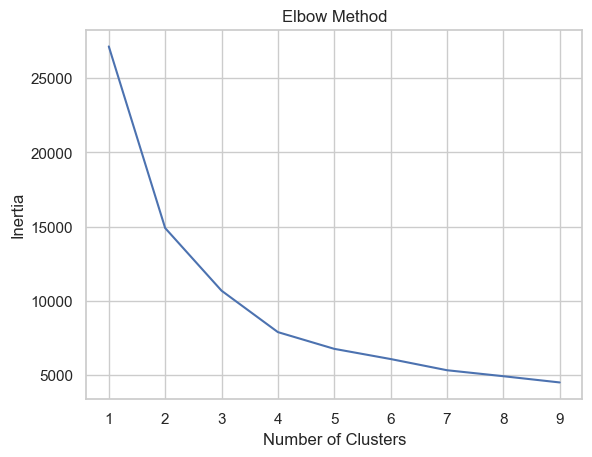

In [ ]:
inertia = []

for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_latent)
    inertia.append(km.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1,10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
db_clusters = dbscan.fit_predict(X_latent)

df['db_cluster'] = db_clusters

In [ ]:
df.groupby('cluster').mean()

,max_ground_temp(°C),min_ground_temp(°C),max_air_temp(°C),min_air_temp(°C),mean_pressure(Pa),anomaly,db_cluster
cluster,,,,,,,
0,-4.918779,-70.805300,9.008065,-75.362903,830.563940,0.039171,-0.071429
1,-0.021493,-72.583710,12.509050,-77.135747,803.243213,0.038462,0.147059
2,-23.532541,-80.514979,-6.960227,-87.385331,816.070764,0.050620,0.066116
3,-16.416757,-74.355822,-0.194777,-79.044614,853.519042,0.065288,0.058760


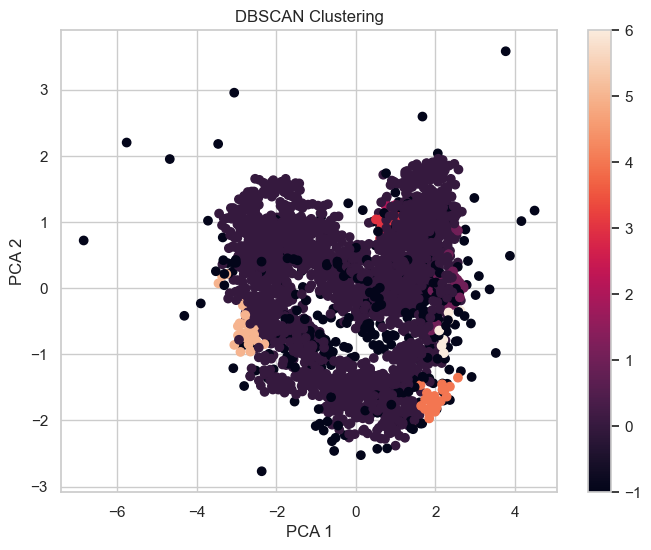

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=db_clusters)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

In [ ]:
anomalies = df[df['db_cluster'] == -1]

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c='blue', label='Normal')
plt.scatter(X_pca[df['db_cluster']==-1, 0],
            X_pca[df['db_cluster']==-1, 1],
            c='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Detection on Mars Data")
plt.show()

KeyboardInterrupt: 

In [ ]:
anomalies.describe()

,max_ground_temp(°C),min_ground_temp(°C),max_air_temp(°C),min_air_temp(°C),mean_pressure(Pa),cluster,db_cluster
count,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.0
mean,-16.742718,-73.864078,-2.160194,-85.567961,809.373786,1.703883,-1.0
std,10.584702,7.884593,12.613139,21.880446,54.537533,1.166477,0.0
min,-67.000000,-100.000000,-61.000000,-136.000000,703.000000,0.000000,-1.0
25%,-24.000000,-78.000000,-8.000000,-100.000000,768.000000,1.000000,-1.0
50%,-16.000000,-75.500000,0.500000,-89.000000,832.000000,2.000000,-1.0
75%,-9.250000,-69.000000,6.000000,-67.250000,852.750000,3.000000,-1.0
max,8.000000,-52.000000,22.000000,-8.000000,903.000000,3.000000,-1.0


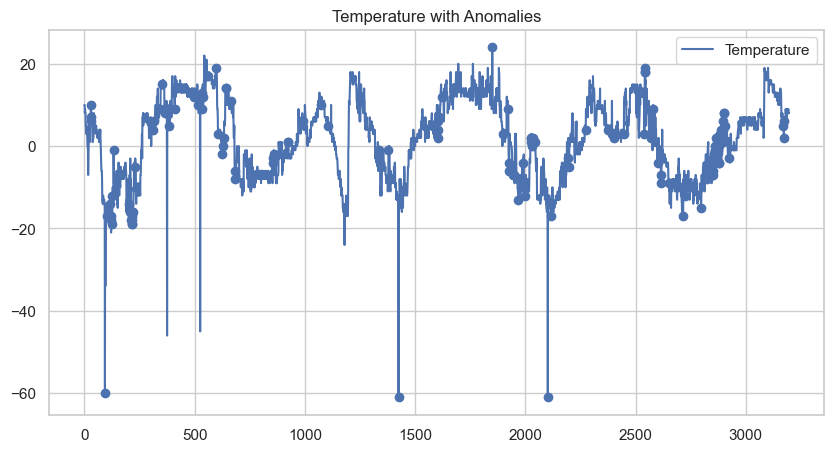

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['max_air_temp(°C)'], label='Temperature')

anomalies = df[df['anomaly'] == True]

plt.scatter(anomalies.index, anomalies['max_air_temp(°C)'])

plt.title("Temperature with Anomalies")
plt.legend()
plt.show()

In [ ]:
import numpy as np

def create_sequences(data, seq_length=10):
    sequences = []

    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])

    return np.array(sequences)

X_seq = create_sequences(X_scaled, seq_length=10)

print(X_seq.shape)

(3187, 10, 5)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

timesteps = X_seq.shape[1]
features = X_seq.shape[2]

input_layer = Input(shape=(timesteps, features))

# Encoder
encoded = LSTM(64, activation='relu')(input_layer)

# Bottleneck
bottleneck = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(64, activation='relu', return_sequences=True)(bottleneck)
decoded = TimeDistributed(Dense(features))(decoded)

lstm_autoencoder = Model(input_layer, decoded)

lstm_autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
history = lstm_autoencoder.fit(
    X_seq, X_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 0.4139 - val_loss: 0.1067
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1481 - val_loss: 0.0625
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1326 - val_loss: 0.0553
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1285 - val_loss: 0.0512
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1249 - val_loss: 0.0493
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1230 - val_loss: 0.0477
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1167 - val_loss: 0.0438
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1134 - val_loss: 0.0431
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1131 - val_loss: 0.0451
Epoch 10/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.1123 - val_loss: 0.0417
Epoch 11/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1087 - val_loss: 0.0411
Epoch 12/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.

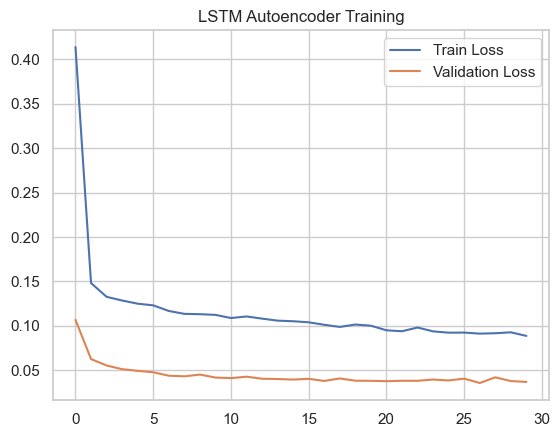

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("LSTM Autoencoder Training")
plt.show()

In [ ]:
X_pred = lstm_autoencoder.predict(X_seq)

recon_error = np.mean((X_seq - X_pred)**2, axis=(1,2))

threshold = np.percentile(recon_error, 95)

anomalies = recon_error > threshold

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step


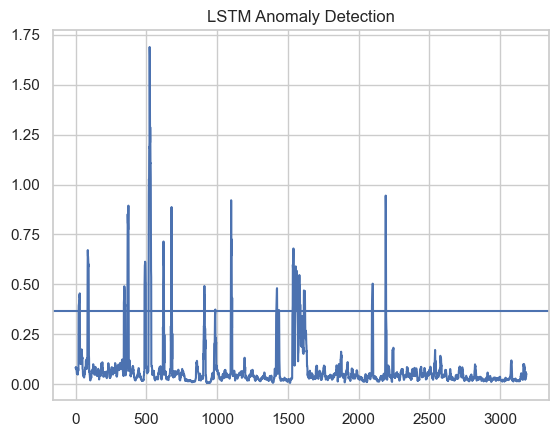

In [ ]:
plt.plot(recon_error)
plt.axhline(threshold)
plt.title("LSTM Anomaly Detection")
plt.show()